# Quantitative Portfolio Optimization developer example
[![Click here to deploy.](https://brev-assets.s3.us-west-1.amazonaws.com/nv-lb-dark.svg)](https://brev.nvidia.com/launchable/deploy?launchableID=env-360InRZzyHqDnJYQKIxaSggF8xI)

![arch_diagram](../docs/arch_diagram.svg)

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 About This Notebook</h4>
This notebook introduces NVIDIA's Quantitative Portfolio Optimization developer example. We use the <strong>Mean-CVaR</strong> model to solve the problem of portfolio asset allocation — step-by-step from raw data to backtested results.
<ul>
<li><strong>Data Preprocessing</strong> — Calculate daily returns from input price data</li>
<li><strong>Scenario Generation</strong> — Use cuML KDE to model returns distribution and generate return scenarios</li>
<li><strong>Model Building</strong> — Build the optimization problem with optional constraints</li>
<li><strong>Solving on GPU</strong> — Call GPU/CPU solvers with customizable settings</li>
<li><strong>Backtesting</strong> — Visualize and evaluate the optimized portfolio</li>
<li><strong>GPU vs CPU Comparison</strong> — Evaluate solver performance across market regimes</li>
</ul>
</div>

## Table of Contents

0. [Portfolio Optimization Setup](#portfolio-optimization-setup)
   - GPU Check
   - Import Libraries

2. [Introduction to Mean-CVaR Optimization](#build-a-mean-cvar-problem)
   - Mathematical Formulation

3. [Data Preprocessing and Model Setup](#data-preprocessing-and-model-setup)
   - Data Preparation
   - Define Problem Parameters
   - Build Mean-CVaR Problem

4. [Solve CVaR Optimization](#solve-cvar-optimization)
   - cuOpt GPU LP Solver
   - CPU Solver Comparison
   - Portfolio Visualization
   - cuOpt GPU MILP Solver

5. [Backtest Portfolio](#backtest-portfolio)
   - Testing Methods
   - Performance Metrics
   - Benchmark Comparison

6. [GPU vs. CPU: Comparison over Different Regimes](#gpu-vs-cpu-comparison-over-different-regimes)
   - Regime Analysis
   - Performance Comparison

7. [Appendix](#appendix)
   - Optional Parameter Constraints
   - cuOpt Python API


---


## 0. Portfolio Optimization Setup
<a id='portfolio-optimization-setup'></a>

Before diving into portfolio optimization, we need to import the necessary libraries and perform initial setup if required.

### 0.1 GPU Check

In [1]:
!nvidia-smi

Fri Mar 13 18:19:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100                    On  |   00000000:6B:00.0 Off |                    0 |
| N/A   44C    P0             64W /  700W |       0MiB /  97871MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### 0.2 Import Libraries

Import the portfolio optimization modules and other required packages.


In [2]:
import os
import cvxpy as cp

from cufolio import cvar_optimizer, cvar_utils, utils
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    ApiSettings,
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)

---

<a id='build-a-mean-cvar-problem'></a>
## 1. Introduction to Mean-CVaR Optimization

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-CVaR Optimization</h4>
The Mean-CVaR model captures the risk-return trade-off, aiming to maximize expected return while minimizing Conditional Value-at-Risk.

Traditionally, variance of portfolio returns is used as the measure of risk. Here, we use <strong>Conditional Value-at-Risk (CVaR)</strong> as an alternative risk measure because it provides a more robust assessment of potential tail losses, and allows a data-driven approach to portfolio optimization without making assumptions on the underlying returns distribution. CVaR measures the average worst-case loss of a return distribution. Formally, for a loss random variable L,
$$\text{CVaR} = {E}[L| L \leq \text{VaR}_\alpha (L)]$$
where  $\text{VaR}(L) = \inf\{l: P(L \leq l) \geq \alpha  \}$ is the $\alpha$-quantile of the loss distribution. CVaR is a more appropriate risk measure for portfolios that may contain assets with asymmetric return distribution - it has replaced Value-at-Risk(VaR) in Basel III market-risk rules; Mathematically, CVaR is a coherent risk measure—satisfying subadditivity, translation invariance, positive homogeneity, and monotonicity—which aligns with the diversification principles. Moreover, it has a computationally tractable transformation as a scenario-based optimization: for confidence level $\alpha$, the CVaR of portfolio ${w}$ can be written in abstract form as 
$$\text{CVaR}({w}) = \min_t\left\{t + \frac{1}{1-\alpha}\sum_{\omega \in \Omega}p(\omega)\max \{\text{loss}({w},\omega) - t, 0\}\right\}, $$
where $\Omega$ is the probability space of returns scenarios and $p(\omega)$ is the probability of a particular scenario $\omega \in \Omega$. Intuitively, this expression represents the portfolio’s average loss below the $\alpha$-quantile of all return scenarios. This scenario-based formulation makes CVaR more robust regardless whether the asset returns distribution is Gaussian or not. When we use linear loss, i.e. $\text{loss}(w,\omega) = -R(\omega){w}$, with $R$ as the return scenarios matrix of size (num_scenarios, num_assets),  the minimization of the CVaR can be transformed into a linear program by replacing the $\max\{\cdot,0\}$ non-negative operator with an auxiliary variable ${u}$: 

\begin{align*}
\text{minimize} \; \quad & t + \frac{1}{1-\alpha}{p}^\top {u},\\
\text{subject to} \quad &{u} +t \geq -R^\top {w},\\
&u\geq 0
\end{align*}



Then, we add constraints to model real-world trading limitations:
- Concentration limits on single assets
- Amount invested in risk-free assets (cash)
- Investment budgets
- Leverage constraints
- Turnover from an existing portfolio
- Cardinality constraints (maximum number of assets allowed in the portfolio)


The mathematical formulation of the problem is given as follows: 
\begin{align*}
\text{maximize } \quad &\mu^\top {w} - \lambda_{\text{ risk}}\left(t + \frac{1}{1-\alpha}p^\top {u}\right)\\
\text{subject to} \quad &{u} +t \geq -R^\top {w}, \, u \geq 0 \quad \text{ (CVaR)}\\
& \sum_i w_i + c = 1\quad \text{(self-financing)}\\
& w_i^{\text{ min}} \leq w_i \leq w_i^{\text{ max}}, \forall i \quad \text{ (concentration)}\\
& c^{\text{ min}} \leq c \leq c^{\text{ max}} \quad \text{ (cash)}\\
& L= \Vert {w} \Vert_1 \leq L^{\text{ limit}} \quad\text{ (leverage)}\\
& T = \Vert {w} - {w}_{\text{ pre}}\Vert_1 \leq T^{\text{ limit}}\quad \text{ (turnover)}
\end{align*}
</div>

## 2. Data Preprocessing and Model Setup
<a id='data-preprocessing-and-model-setup'></a>

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Overview</h4>
We start with an example using a 397-stock subset of the S&P 500 stocks. We aim to build a long-short portfolio that maximizes risk-adjusted returns while meeting custom trading constraints.
</div> 

### 2.1 Data Preparation

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Data Loading</h4>
We load closing prices from <code>2021-01-01</code> to <code>2024-01-01</code> and compute daily log-returns.
<ul>
<li><strong>Historical Dataset</strong> (<code>data_path</code>): CSV file with adjusted closing prices</li>
<li><strong>Regime Information</strong> (<code>regime_dict</code>): select the market regime</li>
<li><strong>Computation Setting</strong> (<code>returns_compute_settings</code>): return type (LOG / NORMAL) and frequency (default 1 = daily)</li>
</ul>
</div>



#### Disclaimer

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>

In [3]:
# User inputs for S&P 500 example
dataset_name = "sp500"
dataset_format = "csv"
data_path = f"../data/stock_data/{dataset_name}.{dataset_format}"

# Download data if not exists
if not os.path.exists(data_path):
    utils.download_data(data_path)

In [4]:
# Set date range
regime_name = "recent" 
time_range = ("2021-01-01", "2024-01-01")


# Define the regime for this example
regime_dict = {"name": regime_name, "range": time_range}

# Define the settings for returns computation
returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)

# Compute returns from price data
returns_dict = utils.calculate_returns(
    data_path,
    regime_dict,
    returns_compute_settings
)

### 2.2 Scenario Generation

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Scenario Generation</h4>
Assume the return distribution is stationary over the optimization period and use historical returns to approximate future ones. We use <code>cuml.KDE</code> on GPU or <code>sklearn.KDE</code> on CPU to fit the return distribution and sample scenarios. Also supports fitting a Multivariate Gaussian distribution. Configure via <code>scenario_generation_settings</code>.
</div>


In [5]:
# Define the settings for scenario generation
scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Generate return scenarios from KDE
returns_dict = cvar_utils.generate_cvar_data(
    returns_dict,
    scenario_generation_settings
)

### 2.3 Define Optimization Parameters

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 CvarParameters</h4>
We define a <code>CvarParameters</code> object to encapsulate key constraints and settings.
<br><br>
<strong>Required:</strong> <code>w_min</code>, <code>w_max</code>, <code>risk_aversion</code>, <code>confidence</code>, <code>num_scen</code>, <code>fit_type</code> — these establish the basic optimization framework.
<br><br>
<strong>Optional:</strong> <code>T_tar</code> (turnover), <code>cvar_limit</code> (max CVaR threshold), <code>cardinality</code> (portfolio size limit). Setting any to a non-<code>None</code> value adds the corresponding constraint.
</div>

In [6]:
# Define CVaR optimization parameters for the S&P 500 example
cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95  # CVaR confidence level (alpha)
)

### 2.4 Build Mean-CVaR Problem

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Problem Construction</h4>
We take the processed data <code>returns_dict</code> and the problem parameters <code>cvar_params</code> and formulate the problem <code>cvar_problem</code>.
</div> 


In [7]:
# Instantiate CVaR optimization problem for the S&P 500 example
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params
)

---

<a id='solve-cvar-optimization'></a>
## 3. Solve CVaR Optimization

### 3.1 cuOpt GPU LP Solver

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 cuOpt Solver Modes</h4>
The cuOpt LP solver supports four solve methods (<code>solver_method</code>):
<ol>
<li><strong>PDLP</strong> — three modes via <code>solver_mode</code>:
  <ul>
  <li><em>Stable2</em>: balance speed and accuracy</li>
  <li><em>Methodical1</em>: prioritize accuracy</li>
  <li><em>Fast1</em>: prioritize speed</li>
  </ul>
</li>
<li><strong>Dual Simplex</strong></li>
<li><strong>Barrier Method</strong></li>
<li><strong>Concurrent</strong>: runs all three and returns the fastest</li>
</ol>
See <a href="https://docs.nvidia.com/cuopt/user-guide/latest/introduction.html">cuOpt documentation</a> for details.
</div>


In [8]:
# GPU solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "solver_method": "PDLP", 
                       "time_limit":15, 
                       "optimality": 1e-4
                       }

# Solve on GPU
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)


CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002524 (0.2524%)
CVaR (95%):          0.024984 (2.4984%)
Objective Value:     -0.001452

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.5447 seconds
CVXPY API Overhead:  0.2173 seconds
Solve Time:          0.9982 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.305 ( 30.47%)
MCK         0.134 ( 13.44%)
NVDA        0.128 ( 12.83%)
IRM         0.118 ( 11.77%)
JBL         0.113 ( 11.34%)
PWR         0.095 (  9.54%)
IT          0.091 (  9.07%)
COP  

In [9]:
gpu_results

regime          recent
solver           CUOPT
solve time    0.998234
return        0.002524
CVaR          0.024984
obj          -0.001452
dtype: object

### 3.2 Solve on CPU solver

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 CPU Comparison</h4>
Using CVXPY as the modeling API, we can easily switch to any CPU solver to solve the same problem. Compare performance and verify that CPU and GPU results match up to the tolerance level — just change the solver in the settings dictionary.
</div>

In [11]:
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=ApiSettings(api="cvxpy")
)

# CPU solver settings
cpu_solver_settings = {"solver":cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}

# Solve on CPU
cpu_results, cpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cpu_solver_settings)


CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002529 (0.2529%)
CVaR (95%):          0.025167 (2.5167%)
Objective Value:     -0.001458

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.2994 seconds
CVXPY API Overhead:  0.2822 seconds
Solve Time:          64.1841 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.278 ( 27.80%)
MCK         0.163 ( 16.29%)
NVDA        0.154 ( 15.36%)
IRM         0.113 ( 11.28%)
IT          0.109 ( 10.90%)
PWR         0.099 (  9.88%)
JBL         0.096 (  9.56%

In [12]:
cpu_results

regime           recent
solver         CLARABEL
solve time    64.184131
return         0.002529
CVaR           0.025167
obj           -0.001458
dtype: object

In [13]:
# Compare results between GPU and CPU solvers
utils.compare_results(gpu_results, cpu_results)


SOLVER COMPARISON
Solver          CVaR         solve time   obj          return      
----------------------------------------------------------------------
CUOPT           0.025160     0.326916     -0.001460    0.002530    
CLARABEL        0.025167     64.184131    -0.001458    0.002529    

Objective Differences:
  CUOPT vs CLARABEL: 0.00000156



### 3.3 Optional: Visualize Optimized Portfolio

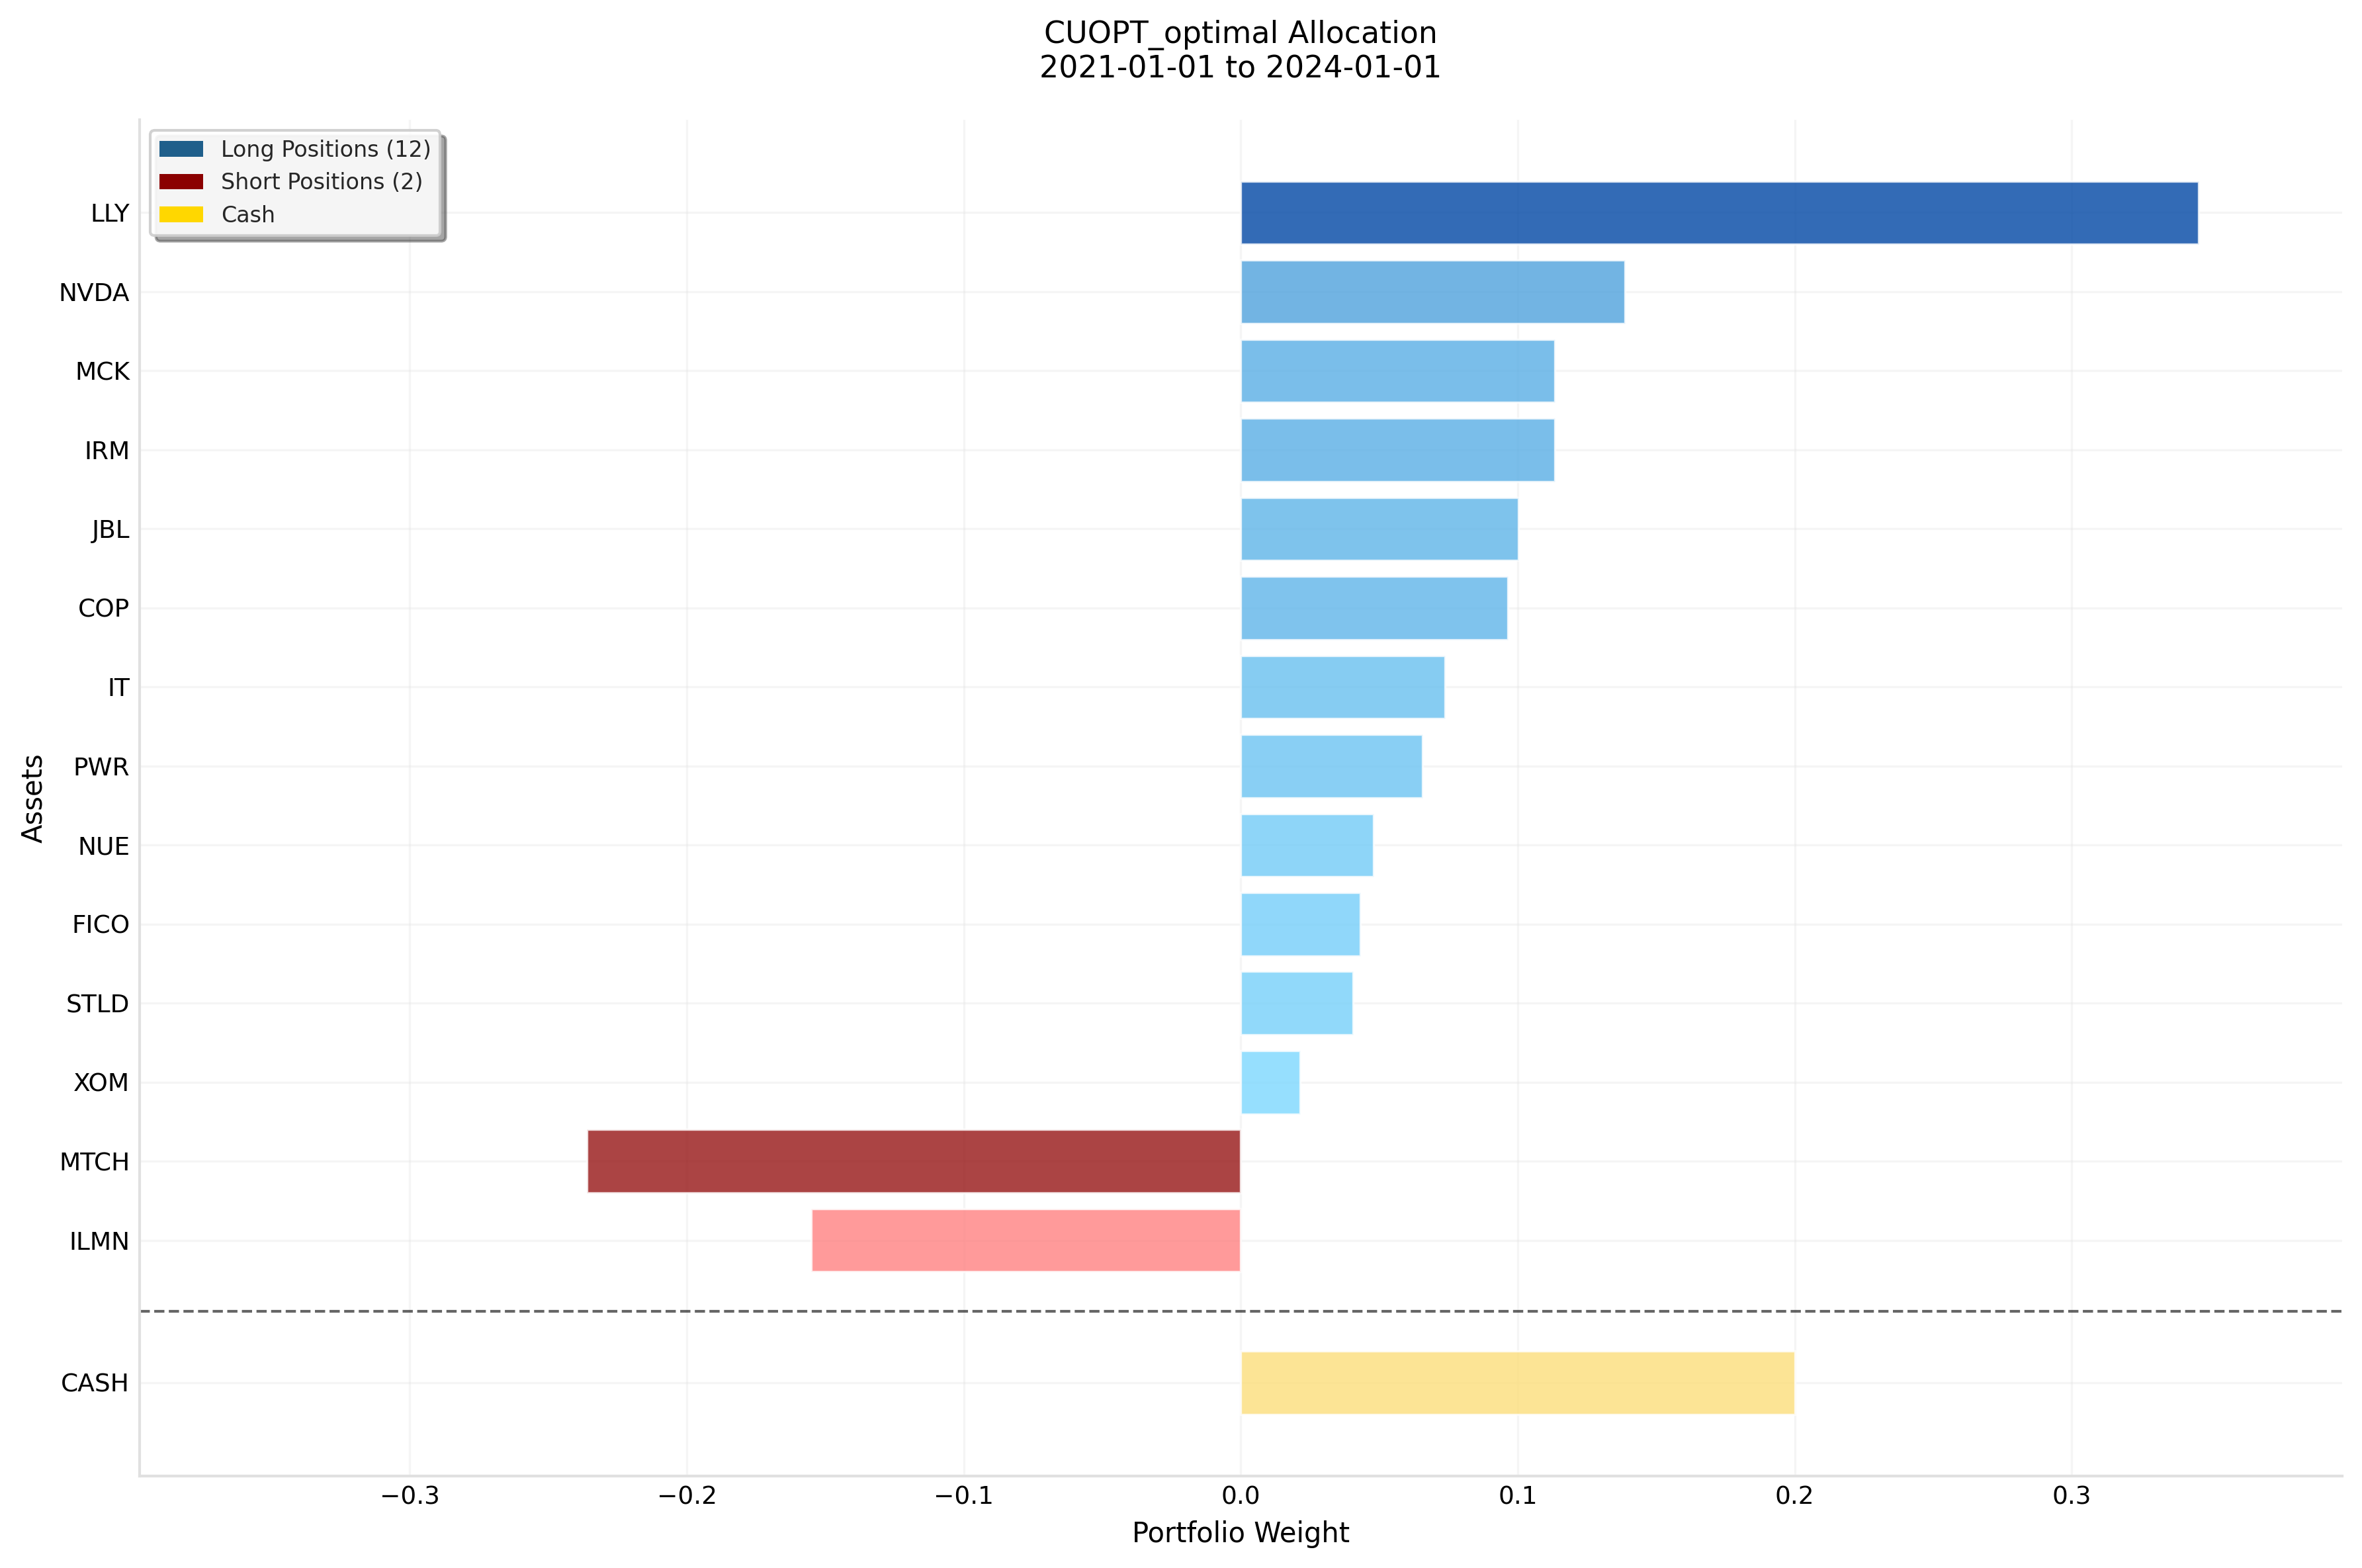

In [16]:
# Plot portfolio
ax = gpu_portfolio.plot_portfolio(show_plot = True, min_percentage = 1)

### 3.4 Adding Cardinality Constraint: Mixed-Integer Linear Program 

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Cardinality Constraint (MILP)</h4>
A <strong>cardinality constraint</strong> limits the maximum number of assets held in the portfolio, promoting sparsity and reducing transaction costs. This constraint transforms the problem into a <strong>Mixed-Integer Linear Program (MILP)</strong> because it requires binary decision variables to track whether each asset is included.

**Mathematical Formulation:**

We introduce binary variables $y_i \in \{0,1\}$ for each asset $i$, where:
- $y_i = 1$ if asset $i$ is held in the portfolio (i.e., $w_i \neq 0$)
- $y_i = 0$ otherwise

The cardinality constraint is then:
$$\sum_{i=1}^{N} y_i \leq K$$
where $K$ is the maximum number of assets allowed. To link the binary variables with the continuous weights, we add:
$$w_i^{\min} \cdot y_i \leq w_i \leq w_i^{\max} \cdot y_i, \quad \forall i$$

This ensures that $w_i = 0$ when $y_i = 0$, and $w_i$ can take non-zero values only when $y_i = 1$. The presence of integer decision variables $y_i$ makes this a MILP.

The complete problem can be written as follows:

\begin{align*}
\text{maximize } \quad & \mu^\top {w} - \lambda_{risk}\left(t + \frac{1}{1-\alpha}p^\top {u}\right),\\
\text{subject to } \quad & {1}^\top {w} = 1,\\
&{u} \geq -R^\top {w} - t,\\
& {w}^{\min} \circ {y} \leq {w} \leq {w}^{\max} \circ {y}, c^{\min} \leq c \leq c^{\max},\\
& L= \Vert {w} \Vert_1 \leq L^{tar},\\
& T = \Vert {w} - {w}_{b}\Vert_1 \leq T^{tar},\\
& \sum{{y}_i} \leq K,\\
&{y}_i \in \{0,1\}^N.
\end{align*}

**Model Set-Up:** 

To set up a MILP problem, we just need to set the `cardinality` to an integer number (max number of assets allowed in the portfolio) when instantiating the `CvarParameters` class. cuOpt offers MILP solvers with a GPU-accelerated heuristics algorithm and a CPU branch-and-cut algorithm. Since MILPs are much challenging to solve in general, we should expect a longer solve time. After solving, one can verify that the number of assets in the portfolio is indeed less than or equal to the cardinality constraint.
</div> 


In [10]:
# Define CVaR optimization parameters for the S&P 500 example
milp_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=10,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# Instantiate the MILP problem
milp_cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=milp_cvar_params
)

# cuOpt MILP solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "time_limit":200, 
                       "mip_absolute_tolerance": 1e-4
                       }

# Solve the MILP problem
milp_results, milp_portfolio = milp_cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)

MIXED-INTEGER LINEAR PROGRAMMING (MILP) SETUP
Cardinality Constraint: K ≤ 10 assets

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              392
Confidence Level:    95.0%
Cardinality Limit:   10 assets

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002542 (0.2542%)
CVaR (95%):          0.025766 (2.5766%)
Objective Value:     -0.001437

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.4982 seconds
CVXPY API Overhead:  0.6325 seconds
Solve Time:          53.7532 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (8 assets)
-------------------------
LLY         0.307 ( 30.67%)
MCK         0.160 ( 15.97%)
NVDA        0.147 ( 14.68%)
JB

## 4. Backtest Portfolio
<a id='backtest-portfolio'></a>

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Backtesting</h4>
The <code>portfolio_backtester</code> evaluates portfolio performance against historical data and benchmarks.
<br><br>
<strong>Testing Methods:</strong> Historical returns, KDE Simulation, Gaussian Simulation
<br>
<strong>Performance Metrics:</strong> Sharpe Ratio, Sortino Ratio, Maximum Drawdown
<br>
<strong>Benchmarking:</strong> Compares against an equal-weight portfolio by default; custom benchmarks supported.
<br><br>
The <code>cut_off_date</code> marks the boundary between training data (used for optimization) and test data (used for out-of-sample evaluation), letting you test robustness to regime shifts.
</div> 

In [35]:
# Define test regime and calculate test returns
test_regime_dict = {"name": "test_recent", "range": ("2023-09-01", "2024-07-01")}
test_returns_dict = utils.calculate_returns(data_path, test_regime_dict, returns_compute_settings)

# Backtest settings
test_method = "historical"
risk_free = 0.0

,returns,cumulative returns,mean portfolio return,sharpe,sortino,max drawdown
portfolio name,,,,,,
CUOPT_optimal,"[0.003340016980252631, 0.0015559887155875698, ...","[1.003345601052201, 1.0049080107159465, 1.0137...",0.003015,3.564069,6.450275,0.069797
AMZN-JPM,"[-0.006441738185377214, -0.010386325944408999,...","[0.99357896533065, 0.9833127368325244, 0.99476...",0.001548,1.966758,3.128698,0.136418
AAPL-MSFT,"[0.009376207633104502, -0.011796972710353425, ...","[1.0094203019727082, 0.9975821626116386, 0.983...",0.001181,1.867661,2.827685,0.073053
NKE-MCD,"[-0.009164032757992137, -0.009069102641945248,...","[0.9908778290183787, 0.9819320825424094, 0.983...",-0.000643,-1.054597,-1.269277,0.192486


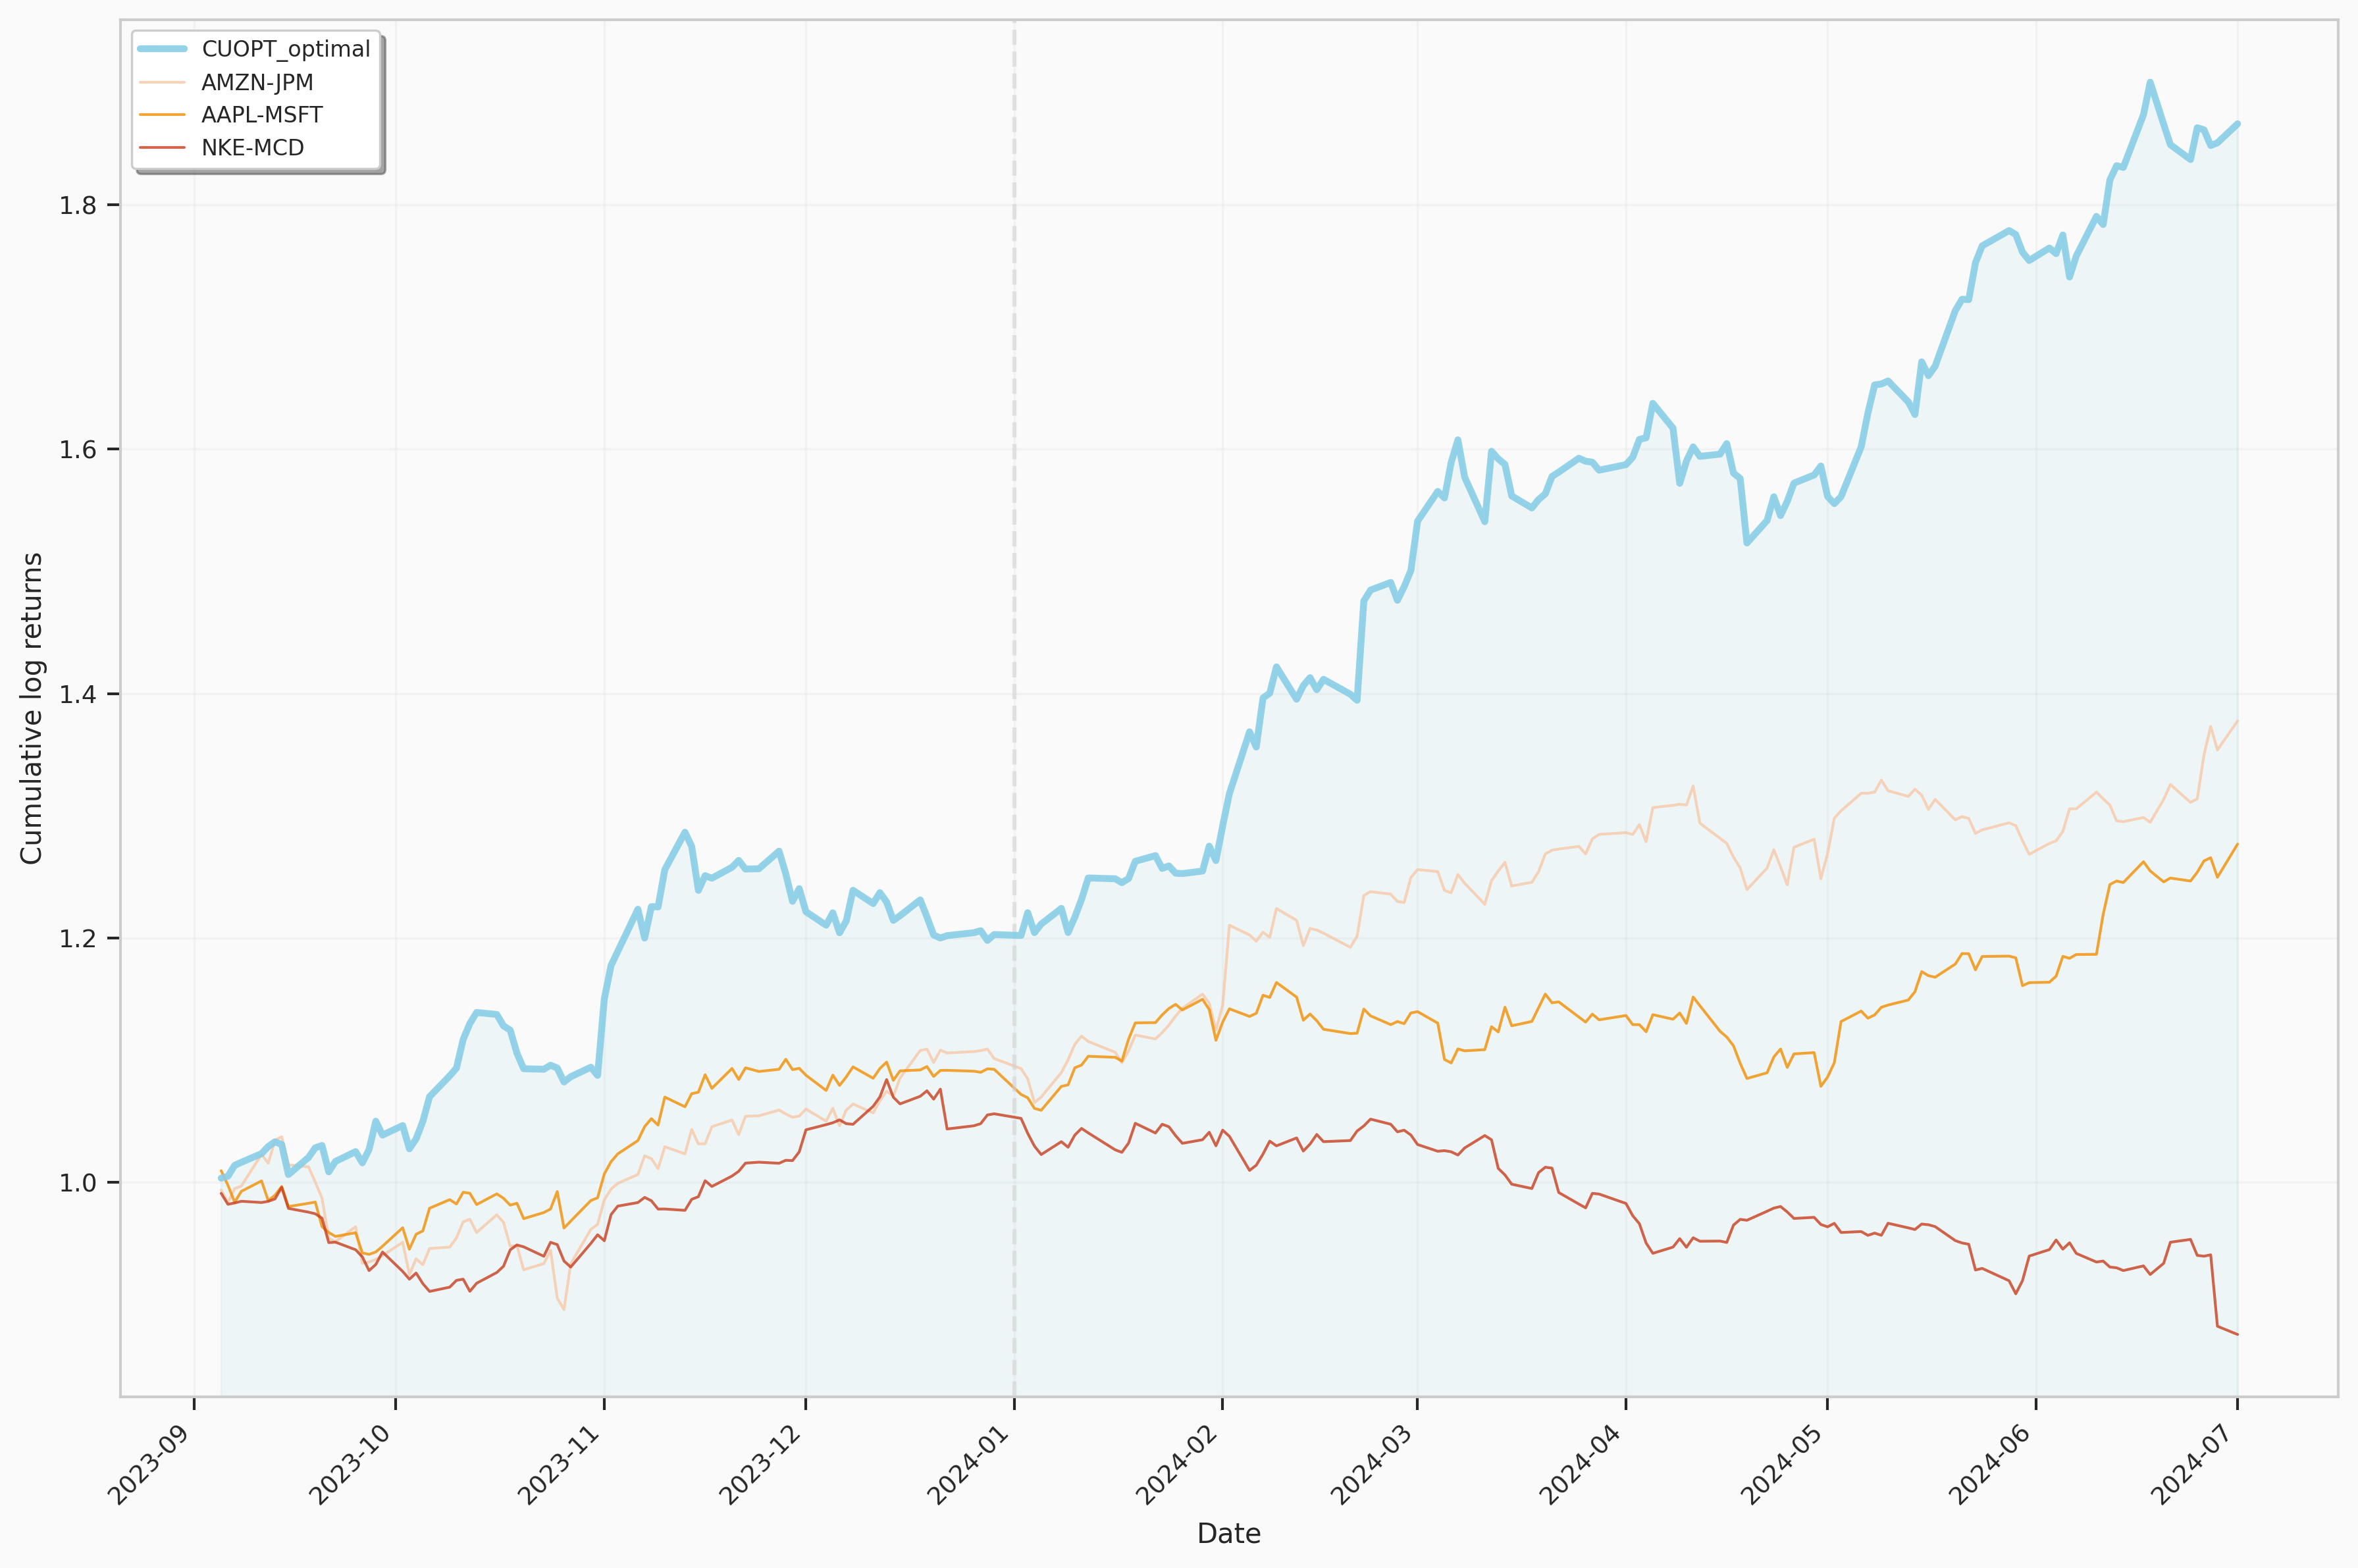

In [36]:
from cufolio import backtest

# (Optional) Compare results between optimized portfolio and user-defined portfolios
portfolios_dict = {'AMZN-JPM':({'AMZN': 0.72, 'JPM': 0.18}, 0.1),\
                   'AAPL-MSFT': ({'AAPL': 0.29, 'MSFT': 0.61}, 0.1),\
                   'NKE-MCD': ({'MCD': 0.65, 'NKE': 0.25}, 0.1)}

benchmark_portfolios = cvar_utils.generate_user_input_portfolios(portfolios_dict, test_returns_dict)

# Uncomment the following lineto use equal-weight benchmark portfolio
# benchmark_portfolios = None 

# Set cut-off date for backtest visualization
cut_off_date = regime_dict["range"][1]

# Create backtester and run backtest
backtester = backtest.portfolio_backtester(gpu_portfolio, test_returns_dict, risk_free, test_method, benchmark_portfolios = benchmark_portfolios)

backtest_result,_ = backtester.backtest_against_benchmarks(plot_returns=True, cut_off_date=cut_off_date)

backtest_result

Combined plot saved: ../results/backtest/combined_cuopt_optimal_historical_analysis.png


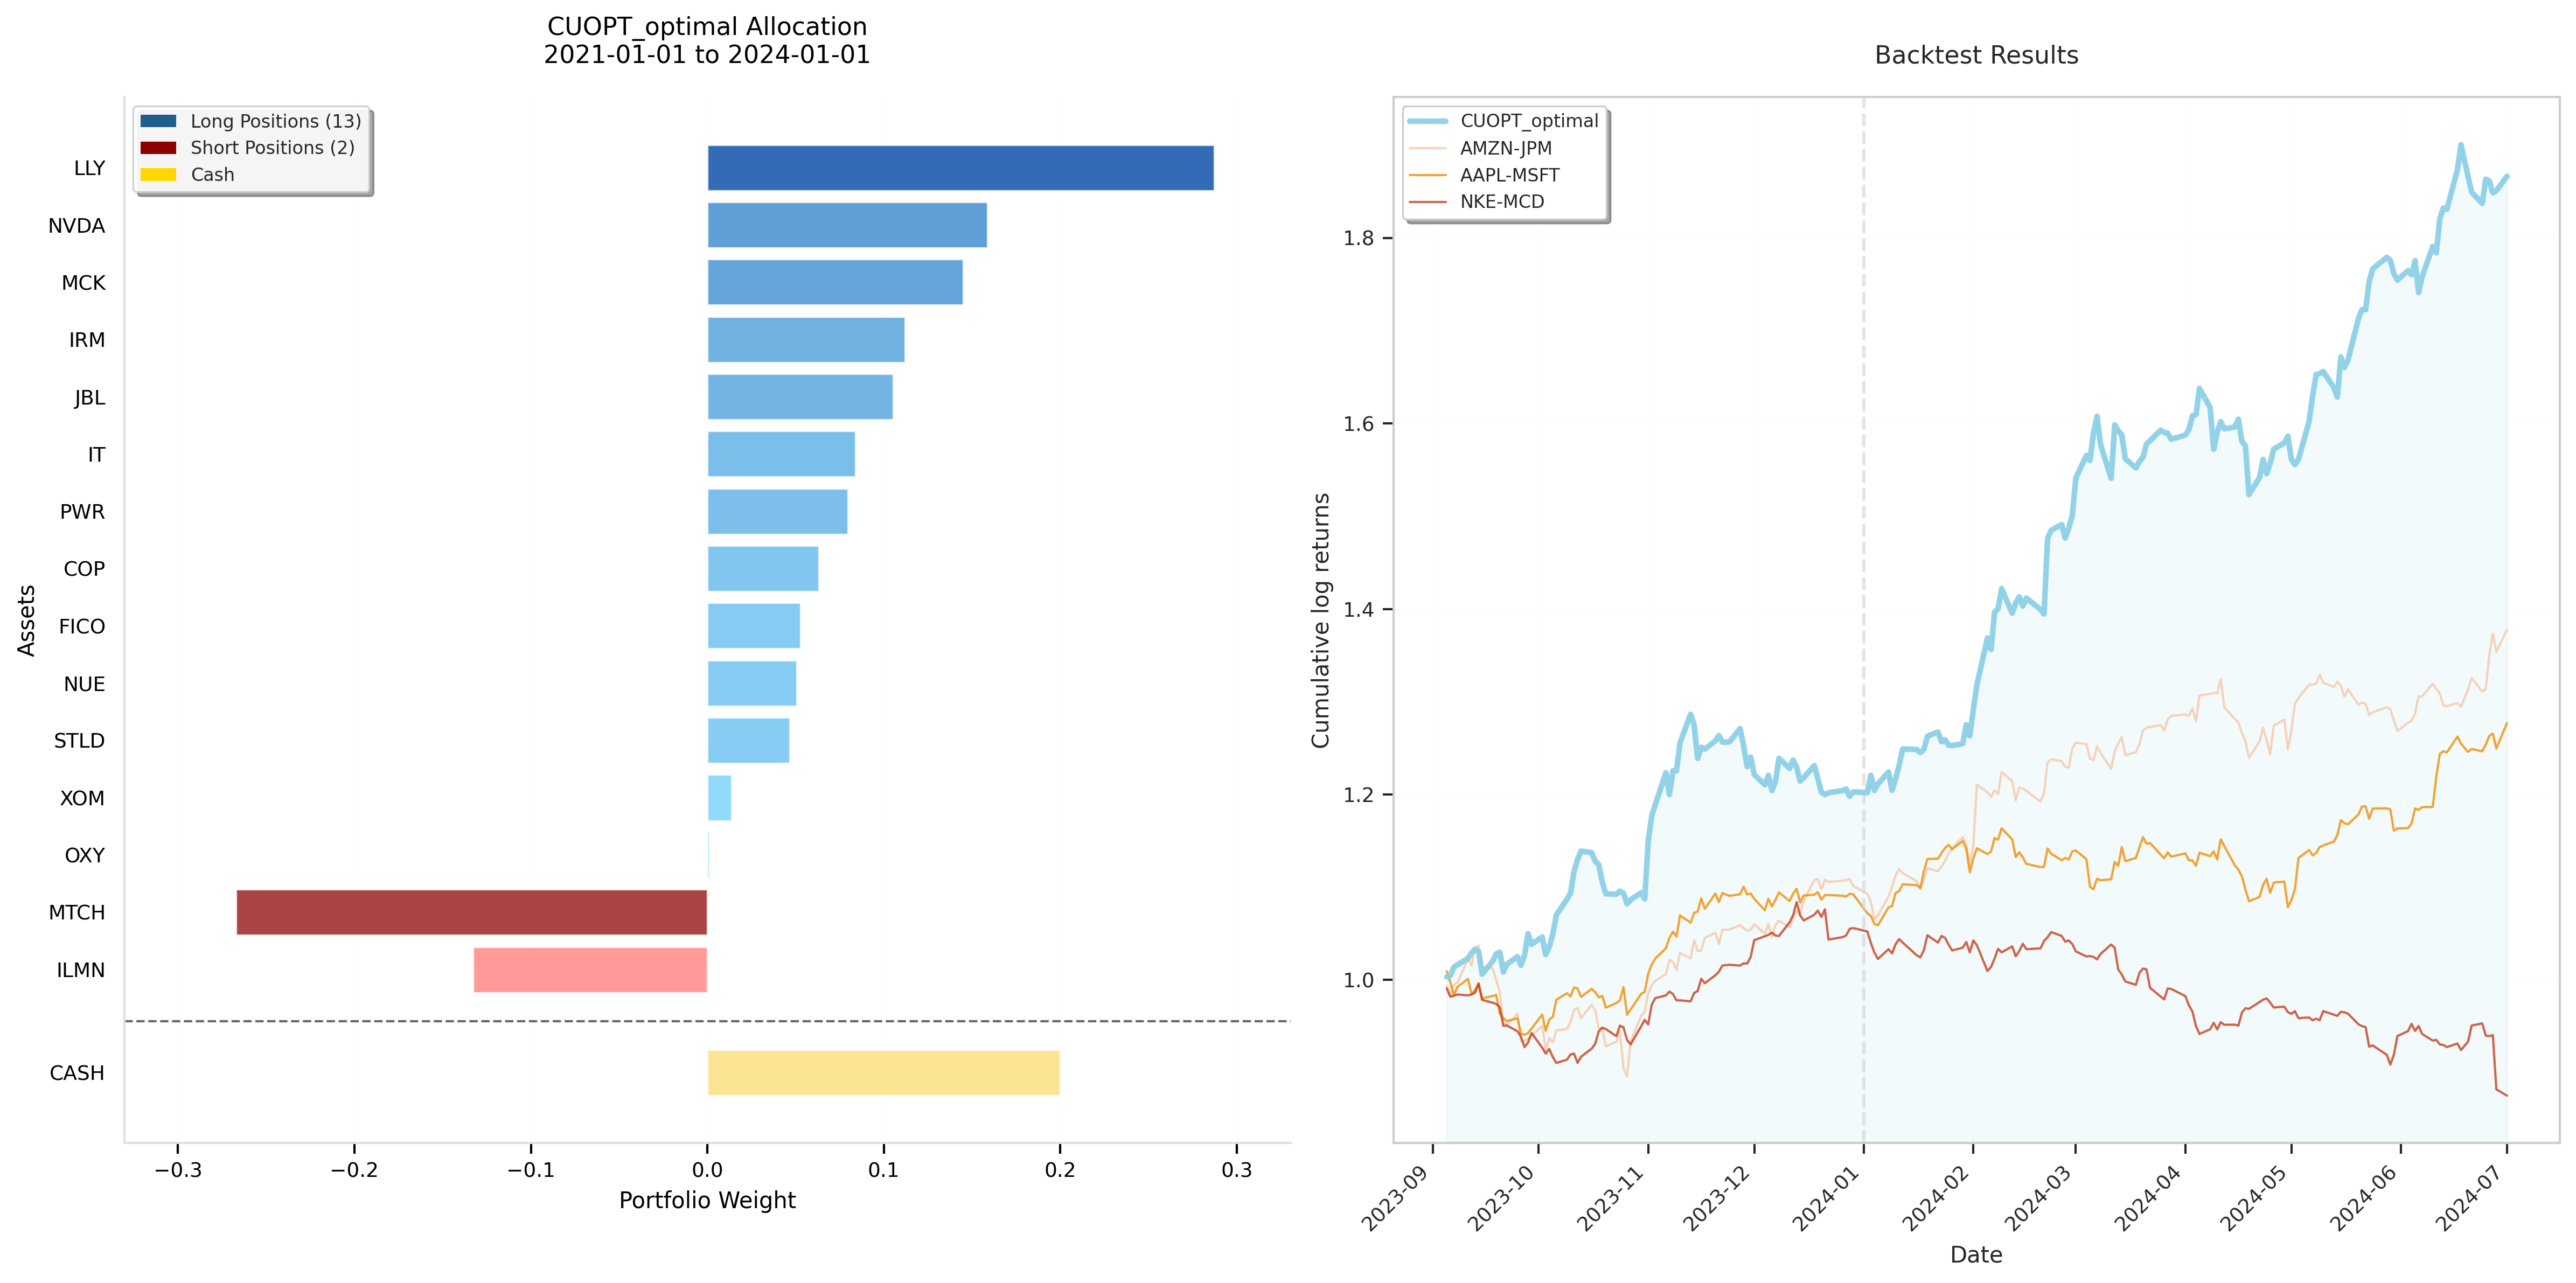

In [37]:
# Plot portfolio and backtest results side by side
utils.portfolio_plot_with_backtest(portfolio=gpu_portfolio, \
                                   backtester=backtester, \
                                   cut_off_date=cut_off_date, \
                                   backtest_plot_title="Backtest Results", \
                                   save_plot = True, \
                                   results_dir = "../results/backtest")

## 5. GPU vs. CPU: Comparison over Different Regimes
<a id='gpu-vs-cpu-comparison-over-different-regimes'></a>

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 Multi-Regime Benchmark</h4>
<code>cvar_utils.optimize_market_regimes</code> generates Mean-CVaR problems iteratively over different regimes from <code>regime_comparison_selected_dict</code>, solves each using all solvers in <code>solver_settings_list</code>, and returns a results dataframe — making it easy to compare GPU vs CPU performance across market conditions.
</div> 

In [6]:
# CVaR parameters for regime comparison
regime_comparison_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality = None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# User inputs for regime comparison
regime_comparison_dataset_name = "sp500"
regime_comparison_num_scen = 5000
regime_comparison_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
regime_comparison_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=regime_comparison_num_scen,
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Prepare output directory and file name
regime_comparison_output_folder = "../results/regime_results"
os.makedirs(regime_comparison_output_folder, exist_ok=True)
regime_comparison_results_csv_path = os.path.join(
    regime_comparison_output_folder,
    f"both_results_{regime_comparison_dataset_name}_{regime_comparison_num_scen}.csv"
)

# Regime settings (customize as needed)
regime_comparison_selected_dict = {
    "pre_crisis"                  : ("2005-01-01", "2007-10-01"),
    "crisis"                      : ("2007-10-01", "2009-04-01"),
    # "post_crisis"                 : ("2009-06-30", "2014-06-30"),
    # "oil_price_crash"             : ("2014-06-01", "2016-03-01"),
    # "FAANG_surge"                 : ("2015-01-01", "2021-01-01"),
    # "covid"                       : ("2020-01-01", "2023-01-01"),
    # "recent"                      : ("2022-01-01", "2024-07-01")
}

# List of solvers to compare - any supported solver on CVXPY can be used.
solver_settings_list = [
    {"solver": cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}, 
    {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP", "optimality": 1e-4}
]

regime_comparison_dataset_path = f"../data/stock_data/{regime_comparison_dataset_name}.csv"

# Run CPU vs. GPU comparison across selected regimes
regime_comparison_results_df = utils.optimize_market_regimes(
    input_file_name=regime_comparison_dataset_path,
    returns_compute_settings=regime_comparison_returns_compute_settings,
    scenario_generation_settings=regime_comparison_scenario_generation_settings,
    all_regimes=regime_comparison_selected_dict,
    params=regime_comparison_cvar_params,
    solver_settings_list=solver_settings_list,
    results_csv_file_name=regime_comparison_results_csv_path
)


Processing Regime: pre_crisis

--- Testing Solver: CLARABEL ---



CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              pre_crisis
Time Period:         2005-01-01 to 2007-10-01
Scenarios:           20,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.003279 (0.3279%)
CVaR (95%):          0.027983 (2.7983%)
Objective Value:     -0.001930

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.3660 seconds
CVXPY API Overhead:  0.6044 seconds
Solve Time:          151.0548 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2005-01-01 to 2007-10-01

LONG POSITIONS (13 assets)
-------------------------
DLR         0.239 ( 23.92%)
AAPL        0.183 ( 18.34%)
MNST        0.182 ( 18.24%)
ILMN        0.108 ( 10.77%)
NVDA        0.100 ( 10.00%)
HOLX        0.084 (  8.41%)
ISRG        0.083 (  

In [7]:
# Display regime comparison results
regime_comparison_results_df

,regime,CLARABEL-obj,CLARABEL-solve_time,CLARABEL-return,CLARABEL-CVaR,CLARABEL-optimal_portfolio,CUOPT-obj,CUOPT-solve_time,CUOPT-return,CUOPT-CVaR,CUOPT-optimal_portfolio
0,pre_crisis,-0.001930,151.054792,0.003279,0.027983,"({'AAPL': 0.18339478777005608, 'AMD': -0.03584...",-0.001930,2.669537,0.003279,0.027959,"({'AAPL': 0.18392649641258285, 'AMD': -0.03570..."
1,crisis,-0.003792,174.621468,0.005055,0.064271,"({'AIG': -0.1797018334478996, 'AZO': 0.3999308...",-0.003797,0.993301,0.005058,0.064198,"({'AIG': -0.1797935923005228, 'AZO': 0.3999999..."


In [8]:
# Show the speed-up ratio of CPU solvers vs cuOpt GPU LP solver 
regime_comparison_results_df.index = regime_comparison_results_df['regime']
speed_comparison_df = regime_comparison_results_df['CLARABEL-solve_time'] / regime_comparison_results_df['CUOPT-solve_time'] # CPU solve time / GPU solve time
speed_comparison_df

regime
pre_crisis     56.584634
crisis        175.799132
dtype: float64

---

<a id='appendix'></a>
## 6. Appendix

### 6.1 Optional: Parameter Constraints

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Faster Iteration with CVXPY Parameters</h4>
Optionally define weight and cash constraints as CVXPY parameters for faster iteration — update bounds without rebuilding the entire problem.
<br><br>
By default, <code>cvar_optimizer.py</code> uses variable bounds:
<pre><code>self.w = cp.Variable(num_assets, name="weights", bounds=[self.params.w_min, self.params.w_max])</code></pre>
because cuOpt LP solver is empirically faster when constraints are set as variable bounds.
</div> 

In [ ]:
# Instantiate CVaR optimization problem for the S&P 500 example
api_settings = ApiSettings(
    api="cvxpy",  # "cvxpy" or "cuopt_python"
    weight_constraints_type="parameter",  # "parameter" or "bounds" (CVXPY only)
    cash_constraints_type="parameter",  # "parameter" or "bounds" (CVXPY only)
)
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=api_settings
)

# Solve on GPU
gpu_solver_settings = {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP"} 
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)


Setting parameter log_to_console to false
Setting parameter method to 1

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              397
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002564 (0.2564%)
CVaR (95%):          0.026241 (2.6241%)
Objective Value:     -0.001444

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.2900 seconds
CVXPY API Overhead:  0.0862 seconds
Solve Time:          0.4592 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.328 ( 32.81%)
NVDA        0.151 ( 15.06%)
MCK         0.144 ( 14.43%)
JBL         0.136 ( 13.59%)
IT          0.103

### 6.2 Optional: cuOpt Python API

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Native cuOpt API</h4>
Instead of using CVXPY, you can build the problem directly with the cuOpt native Python API by choosing <code>api_settings</code>.
</div>


In [8]:
# Instantiate CVaR optimization problem using cuOpt Python API
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=ApiSettings(api="cuopt_python")
)

# Solver settings for cuOpt Python API
cuopt_settings = {"log_to_console":True, "presolve": False, "method": 1}

# Solve using cuOpt Python API
cuopt_gpu_results, cuopt_gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cuopt_settings)


cuOpt PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 10000 auxiliary + 1 threshold
           + 784 leverage decomposition
Constraints: Budget + 10000 CVaR scenarios + additional constraints
Problem Type: LP
Setting parameter log_to_console to true
Setting parameter presolve to false
Setting parameter method to 1
cuOpt version: 25.12.0, git hash: d97ff6b, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480CL, threads (physical/logical): 112/224, RAM: 1340.13 GiB
CUDA 13.0, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: 7effffffa24967-ffffffe525-2e27-fffff

Solving a problem with 10394 constraints, 11178 variables (0 integers), and 3942353 nonzeros
Problem scaling:
Objective coefficents range:          [6e-07, 4e-02]
Constraint matrix coefficients range: [1e-08, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party p

SPDX-FileCopyrightText: Copyright (c) 2023-2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved. 

SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.